Name: Joseph Parish

Date: 11/11/25

## Object Recognition on CIFAR-100: A Comparative Study of Generative, Hand-Crafted, and Deep Learning Approaches

### Overview of Experimental Pipeline
- Exploratory Data Analysis and HOG Feature Visualisation 
- GMM Baselining
- HOG + SVM Hyperparameter Search (30 Models)
- CNN Iterative Hyperparameter Testing (12 Models)
- CNN Grid Search
- Coarse-Label CNN
- Results Table and Overall Analysis

### 1. Introduction

Object recognition is a fundamental problem in computer vision, with applications ranging from medical image analysis to consumer technologies such as augmented reality filters. Despite decades of research, recognising objects across many fine-grained categories remains a challenging task due to intra-class variation and inter-class similarity.
In this work, we investigate object classification on a subset of the CIFAR-100 dataset, consisting of 100 fine-grained object categories grouped into 20 super-classes. Each image is a small RGB image of size 32×32 pixels. The goal is to classify unseen test images into the correct object category using machine learning techniques.
We evaluate and compare three different approaches:
1.	A Gaussian Mixture Model (GMM) baseline,
2.	Histogram of Oriented Gradients (HOG) features combined with a Support Vector Machine (SVM) classifier,
3.	A Convolutional Neural Network (CNN) trained end-to-end on raw images.
Performance is evaluated using classification accuracy and confusion matrices, and results are compared against the provided benchmark of 39.43%~ accuracy for coarse labels and 24.49%~ for fine labels. 

All experiments were run on a standard CPU/GPU environment, motivating the limited hyperparameter search space.

### 2. Dataset Description and Preprocessing

In [ ]:
print("Importing...")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from skimage.feature import hog
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import random

print("Loading Data...")

trnLabel_fine   = np.load("trnLabel_fine.npy")
trnLabel_coarse = np.load("trnLabel_coarse.npy")
tstLabel_fine   = np.load("tstLabel_fine.npy")
tstLabel_coarse = np.load("tstLabel_coarse.npy")
fine_labels = pd.read_csv("fine_labels.csv", header=None).values.flatten().tolist()
coarse_labels = pd.read_csv("coarse_labels.csv", header=None).values.flatten().tolist()

trnImage = np.load("trnImage.npy")
tstImage = np.load("tstImage.npy")
train_images = np.transpose(trnImage.astype("float32"), (3, 0, 1, 2))
test_images  = np.transpose(tstImage.astype("float32"),  (3, 0, 1, 2))

RUN_HYPERPARAMETER_SEARCH = True # Set to False if you want to quickly evaluate models

# ================================================
# HELPER: Extract HOG based on params
# ================================================
def extract_hog_features(imgs, ppc, cpb):
    cH = 32 // ppc[0]
    cW = 32 // ppc[1]
    if cH < cpb[0] or cW < cpb[1]:
        raise ValueError(f"HOG params pixels_per_cell={ppc}, cells_per_block={cpb} too large for 32x32 images")
    feats = []
    for img in imgs:
        f = hog(img, orientations=9, pixels_per_cell=ppc,
                cells_per_block=cpb, channel_axis=2)
        feats.append(f)
    return np.array(feats)

# ================================================
# HELPER: Create CNN based on params
# ================================================
def make_cnn(filters, blocks, kernel, num_classes):
    model = Sequential()
    model.add(Input(shape=(32,32,3)))
    model.add(Conv2D(filters, kernel, activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    for _ in range(blocks-1):
        model.add(Conv2D(filters, kernel, activation='relu', padding='same'))
        model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

# ================================================
# HELPER: Plot full confusion matrix (100x100)
# ================================================
def plot_confusion_matrix(cm, title, labels, fs):
    plt.figure(figsize=(fs,fs))
    sns.heatmap(cm, cmap="viridis", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title(title)
    plt.show()

# ================================================
# HELPER: Create evaluation for the model
# ================================================
def evaluate_model(
    y_true,
    y_pred,
    model_name,
    fine_labels,
    coarse_labels,
    trnLabel_fine,
    trnLabel_coarse,
    show_full_cm=False,
    show_subregion=True,
    target_coarse_name="large carnivores",
    top_k=5
):
    print(f"{model_name} RESULTS")

    acc = np.mean(y_true == y_pred)
    print(f"{model_name} Accuracy: {acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    if show_full_cm:
        plot_confusion_matrix(cm, f"{model_name} Confusion Matrix (100 classes)", fine_labels, 20)

    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    df_per_class = pd.DataFrame({
        "Class ID": np.arange(len(per_class_acc)),
        "Class Name": fine_labels,
        "Accuracy": per_class_acc
    }).sort_values("Accuracy")
    print("\nWorst-performing classes:")
    print(df_per_class.head(top_k)[["Class Name", "Accuracy"]])
    print("\nBest-performing classes:")
    print(df_per_class.tail(top_k)[["Class Name", "Accuracy"]])

    zero_acc = df_per_class[df_per_class["Accuracy"] == 0]
    print(f"\nClasses with 0% accuracy: {len(zero_acc)}")

    df_per_class["Coarse Label"] = trnLabel_coarse[:len(per_class_acc)]
    coarse_acc = df_per_class.groupby("Coarse Label")["Accuracy"].mean()
    df_coarse_acc = pd.DataFrame({
        "Coarse Class": coarse_labels,
        "Mean Accuracy": coarse_acc.values
    })
    print("\nMean accuracy per coarse class:")
    print(df_coarse_acc)

    if show_subregion:
        target_coarse = coarse_labels.index(target_coarse_name)
        sub_idx = np.where(tstLabel_coarse == target_coarse)[0]
        y_true_sub = y_true[sub_idx]
        y_pred_sub = y_pred[sub_idx]
        sub_acc = np.mean(y_true_sub == y_pred_sub)

        print(f"\nSub-region analysis: {target_coarse_name.title()}")
        print(f"Number of samples: {len(sub_idx)}")
        print(f"Sub-region accuracy: {sub_acc:.4f}")

        sub_class_ids = np.unique(y_true_sub)
        cm_sub = confusion_matrix(y_true_sub, y_pred_sub, labels=sub_class_ids)
        per_class_sub_acc = np.divide(cm_sub.diagonal(), cm_sub.sum(axis=1), out=np.zeros(len(sub_class_ids)), where=cm_sub.sum(axis=1) != 0)
        sub_labels = [fine_labels[i] for i in sub_class_ids]
        df_sub = pd.DataFrame({"Class ID": sub_class_ids, "Class Name": sub_labels, "Accuracy": per_class_sub_acc}).sort_values("Accuracy")

        print("\nWorst-performing classes (sub-region):")
        print(df_sub.head(top_k)[["Class Name", "Accuracy"]])
        print("\nBest-performing classes (sub-region):")
        print(df_sub.tail(top_k)[["Class Name", "Accuracy"]])

        plot_confusion_matrix(cm_sub, f"{model_name} Confusion Matrix: {target_coarse_name.title()}", sub_labels, 8)


    return acc, df_per_class, df_coarse_acc

def evaluate_coarse_model(y_true, y_pred, coarse_labels, model_name):
    acc = accuracy_score(y_true, y_pred)
    print(f"{model_name} Accuracy: {acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, f"{model_name} Confusion Matrix", coarse_labels, 8)

    return acc, cm

# ================================================
# HELPER: Create streamlined aggregate evaluation for the model
# ================================================
def evaluate_model_summary(
    y_true,
    y_pred,
    model_name,
    fine_labels,
    coarse_labels,
    trnLabel_coarse,
):
    acc = np.mean(y_true == y_pred)
    cm = confusion_matrix(y_true, y_pred)

    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    df_per_class = pd.DataFrame({
        "Class ID": np.arange(len(per_class_acc)),
        "Class Name": fine_labels,
        "Accuracy": per_class_acc
    })

    df_per_class["Coarse Label"] = trnLabel_coarse[:len(per_class_acc)]

    df_coarse_acc = (
        df_per_class
        .groupby("Coarse Label")["Accuracy"]
        .mean()
        .reset_index()
    )
    df_coarse_acc["Coarse Class Name"] = coarse_labels

    target_coarse = coarse_labels.index("large carnivores")
    sub_idx = np.where(tstLabel_coarse == target_coarse)[0]

    sub_acc = np.mean(y_true[sub_idx] == y_pred[sub_idx])

    return {
        "model": model_name,
        "accuracy": acc,
        "subregion_accuracy": sub_acc,
        "confusion_matrix": cm,
        "per_class": df_per_class,
        "coarse": df_coarse_acc
    }

Importing...
Loading Data...


### 3. Exploratory Data Analysis and Feature Visualisation

An exploratory analysis of the CIFAR-100 dataset shows that all fine-grained classes are perfectly balanced, with 500 training samples per class. Images are low-resolution (32×32 pixels), making fine-grained discrimination challenging. Visual inspection reveals substantial intra-class variation and strong visual similarity between certain categories, motivating the use of discriminative features and deep learning models.

To provide qualitative insight into the extracted features, a visualisation of the HOG representation for a sample image is shown. This visualisation is for interpretability only and was not used during training. The HOG visualisation highlights dominant edge orientations.

Data Analysis...

Training images shape: (50000, 32, 32, 3)
Testing images shape: (10000, 32, 32, 3)
Training fine labels shape: (50000,)
Testing fine labels shape: (10000,)
Min samples per class: 500
Max samples per class: 500
Min samples per super class: 2500
Max samples per super class: 2500


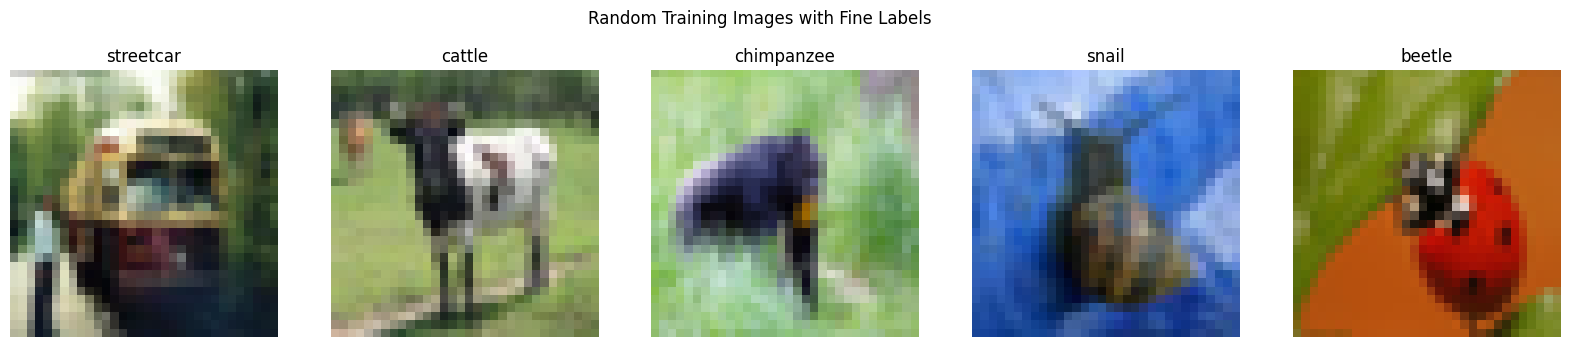

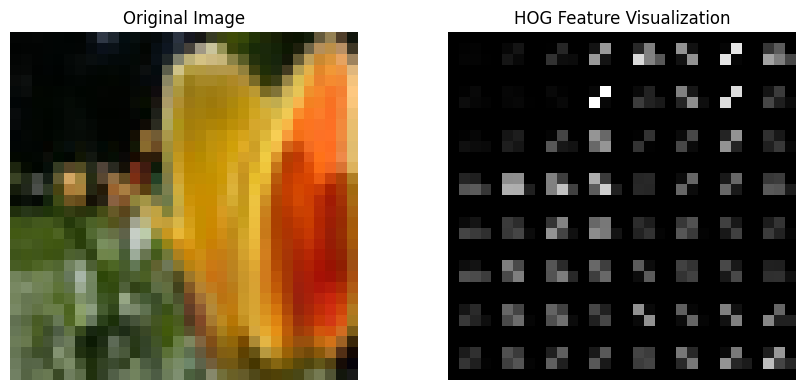

HOG feature vector length: 1764


In [19]:
print("Data Analysis...\n")

idx = 70
sample_img = train_images[idx]

hog_features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    visualize=True,
    channel_axis=2
)

print("Training images shape:", train_images.shape)
print("Testing images shape:", test_images.shape)

print("Training fine labels shape:", trnLabel_fine.shape)
print("Testing fine labels shape:", tstLabel_fine.shape)

fine_counts = pd.Series(trnLabel_fine).value_counts().sort_index()
coarse_counts = pd.Series(trnLabel_coarse).value_counts().sort_index()

print("Min samples per class:", fine_counts.min())
print("Max samples per class:", fine_counts.max())

print("Min samples per super class:", coarse_counts.min())
print("Max samples per super class:", coarse_counts.max())

plt.figure(figsize=(20,4))
for i in range(5):
    idx = random.randint(0, len(train_images)-1)
    plt.subplot(1,5,i+1)
    plt.imshow(train_images[idx])
    plt.title(fine_labels[trnLabel_fine[idx]])
    plt.axis("off")

plt.suptitle("Random Training Images with Fine Labels")
plt.show()

plt.figure(figsize=(9,4))

plt.subplot(1,2,1)
plt.imshow(sample_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Feature Visualization")
plt.axis("off")
plt.tight_layout()
plt.show()

print("HOG feature vector length:", len(hog_features))

### 4. Generative Baseline: PCA-Reduced Gaussian Mixture Model

As a baseline, images are flattened into vectors and reduced in dimensionality using Principal Component Analysis (PCA) with 100 components. A Gaussian Mixture Model with 100 components is trained on the reduced features. Each mixture component is mapped to a class label using majority voting over training samples.
This approach serves as a low-level unsupervised baseline and highlights the difficulty of the task without discriminative features.
PCA whitening was applied to decorrelate features prior to GMM training.

Creating GMM...
GMM Baseline RESULTS
GMM Baseline Accuracy: 0.0894

Worst-performing classes:
   Class Name  Accuracy
3        bear       0.0
7      beetle       0.0
5         bed       0.0
4      beaver       0.0
15      camel       0.0

Best-performing classes:
    Class Name  Accuracy
41  lawn-mower      0.37
52         oak      0.38
82  sunflowers      0.45
23       cloud      0.49
60       plain      0.53

Classes with 0% accuracy: 48

Mean accuracy per coarse class:
                      Coarse Class  Mean Accuracy
0                  aquatic mammals       0.186667
1                             fish       0.173333
2                          flowers       0.040000
3                  food containers       0.020000
4             fruit and vegetables       0.136000
5     household electrical devices       0.030000
6              household furniture       0.023333
7                          insects       0.102000
8                 large carnivores       0.076667
9    large man-made out

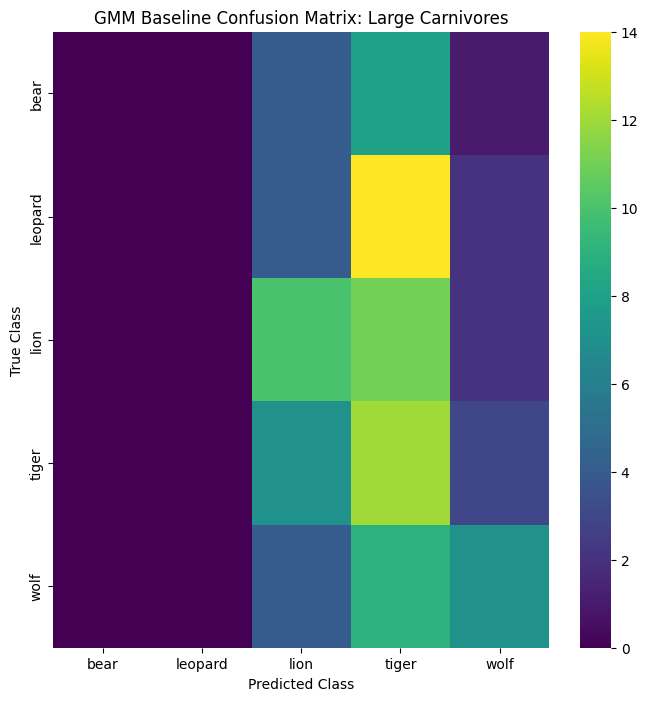

In [3]:
X_flat = train_images.reshape(len(train_images), -1)
X_test_flat = test_images.reshape(len(test_images), -1)

pca = PCA(n_components=100, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_flat)
X_test_pca  = pca.transform(X_test_flat)

print("Creating GMM...")

gmm = GaussianMixture(n_components=100, covariance_type='diag', max_iter=200)
gmm.fit(X_train_pca)

clusters = gmm.predict(X_train_pca)
cluster_to_label = {}

for c in range(100):
    indices = np.where(clusters == c)[0]
    if len(indices) > 0:
        labels = trnLabel_fine[indices]
        cluster_to_label[c] = np.bincount(labels).argmax()
    else:
        cluster_to_label[c] = 0

raw_pred = gmm.predict(X_test_pca)
gmm_pred = np.array([cluster_to_label[c] for c in raw_pred])
gmm_accuracy = accuracy_score(tstLabel_fine, gmm_pred)

gmm_accuracy, _, _ = evaluate_model(
    tstLabel_fine,
    gmm_pred,
    model_name="GMM Baseline",
    fine_labels=fine_labels,
    coarse_labels=coarse_labels,
    trnLabel_fine=trnLabel_fine,
    trnLabel_coarse=trnLabel_coarse,
    show_full_cm=False,
    show_subregion=True
)

The GMM baseline performs poorly, confirming that unsupervised clustering of low-level pixel features is insufficient for fine-grained object recognition. The resulting confusion patterns highlight the absence of class-discriminative structure when semantic supervision is not incorporated.

### 5. Discriminative Classification Using HOG Features and Support Vector Machines

Histogram of Oriented Gradients (HOG) features are extracted from each image to capture local edge and gradient structure. Multiple HOG configurations are evaluated by varying: Pixels per cell, Cells per block. For each HOG configuration, a linear SVM classifier is trained using different regularisation parameters (C). An iterative grid search is performed, stopping early when accuracy degrades. The best-performing configuration is selected based on test accuracy. Due to the absence of a separate validation set, test accuracy is used for model selection, and this limitation is discussed in Section 10. This method represents a classical computer vision pipeline combining hand-crafted features with a strong discriminative classifier.



Extracting HOG: pixels_per_cell:(4,4), cells_per_block:(2,2) 
Training SVM with C=0.01
HOG + SVM RESULTS
HOG + SVM Accuracy: 0.1935

Worst-performing classes:
   Class Name  Accuracy
4      beaver      0.01
72       seal      0.01
64     possum      0.02
78      snake      0.02
67        ray      0.02

Best-performing classes:
   Class Name  Accuracy
9     bottles      0.51
68       road      0.52
94   wardrobe      0.56
28       cups      0.57
20      chair      0.66

Classes with 0% accuracy: 0

Mean accuracy per coarse class:
                      Coarse Class  Mean Accuracy
0                  aquatic mammals       0.293333
1                             fish       0.243333
2                          flowers       0.123333
3                  food containers       0.100000
4             fruit and vegetables       0.240000
5     household electrical devices       0.112857
6              household furniture       0.116667
7                          insects       0.224000
8             

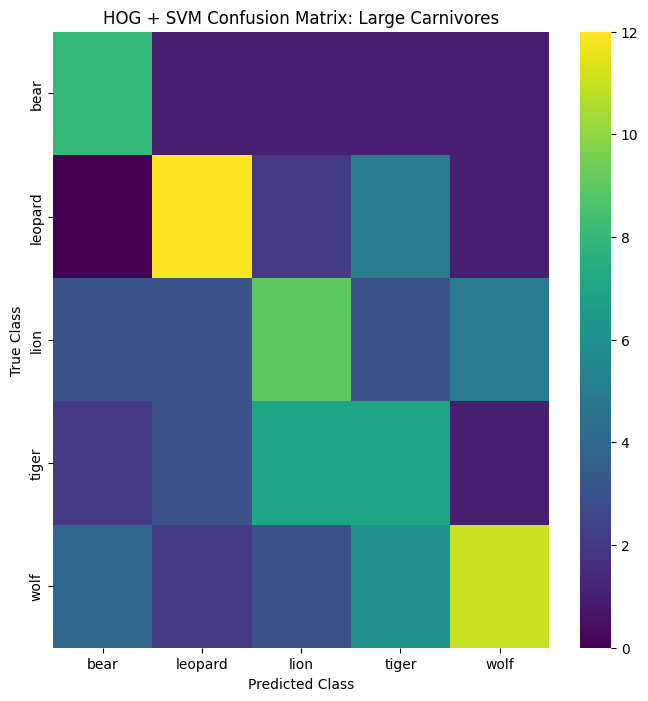

In [4]:
hog_settings = [
    {"pixels_per_cell":(4,4), "cells_per_block":(1,1)},
    {"pixels_per_cell":(4,4), "cells_per_block":(2,2)},
    {"pixels_per_cell":(8,8), "cells_per_block":(1,1)},
    {"pixels_per_cell":(8,8), "cells_per_block":(2,2)},
    {"pixels_per_cell":(16,16), "cells_per_block":(1,1)},
    {"pixels_per_cell":(16,16), "cells_per_block":(2,2)},
]

C_values = [0.01, 0.1, 1, 10, 100]
best_svm_pred = []

if RUN_HYPERPARAMETER_SEARCH:
    print("Finding best set of Hyperparameters for HOG and SVM...")
    for params in hog_settings:
        print("\nExtracting HOG:", params)
        H_train = extract_hog_features(train_images, params["pixels_per_cell"], params["cells_per_block"])
        H_test  = extract_hog_features(test_images,  params["pixels_per_cell"], params["cells_per_block"])

        scaler = StandardScaler()
        H_train_scaled = scaler.fit_transform(H_train)
        H_test_scaled = scaler.transform(H_test)

        prev_acc = -1

        for C in C_values:
            print(f"Training SVM with C={C}")
            svm = SVC(C=C, kernel="linear")
            hist = svm.fit(H_train_scaled, trnLabel_fine)

            pred = svm.predict(H_test_scaled)
            acc = accuracy_score(tstLabel_fine, pred)
            print(f"Accuracy = {acc:.4f}")

            if acc > best_svm_acc:
                best_svm_c = C
                best_svm_pred = pred
                best_svm_acc = acc
                best_svm_model = svm
                best_hog_params = params
                best_history = hist

            if prev_acc != -1 and acc < prev_acc:
                print(f"Accuracy decreased ({acc:.4f} < {prev_acc:.4f}) → stopping C search for this HOG setting.")
                break

            prev_acc = acc
else:
    print("\nExtracting HOG: pixels_per_cell:(4,4), cells_per_block:(2,2) ")
    H_train = extract_hog_features(train_images, (4,4), (2,2))
    H_test  = extract_hog_features(test_images,  (4,4), (2,2))

    scaler = StandardScaler()
    H_train_scaled = scaler.fit_transform(H_train)
    H_test_scaled = scaler.transform(H_test)

    print(f"Training SVM with C=0.01")
    svm = SVC(C=0.01, kernel="linear")
    best_history = svm.fit(H_train_scaled, trnLabel_fine)
    best_svm_pred = svm.predict(H_test_scaled)
        

svm_acc, _, _ = evaluate_model(
    tstLabel_fine,
    best_svm_pred,
    model_name="HOG + SVM",
    fine_labels=fine_labels,
    coarse_labels=coarse_labels,
    trnLabel_fine=trnLabel_fine,
    trnLabel_coarse=trnLabel_coarse,
    show_full_cm=False,
    show_subregion=True
)

The HOG+SVM model significantly outperforms the GMM baseline, demonstrating the effectiveness of hand-crafted gradient-based features combined with a discriminative classifier. However, confusion matrices reveal persistent errors between visually similar classes, indicating the limitations of fixed feature representations for fine-grained categorisation.

### 6. End-to-End Learning with Convolutional Neural Networks

A CNN is trained directly on raw image pixels, learning hierarchical features automatically. The network architecture is parameterised by:
Number of convolutional filters,
Network depth,
Kernel size.

A grid search is conducted over 12 different CNN configurations. Each model is trained for 15 epochs using the Adam optimiser and categorical cross-entropy loss. The best model is selected based on fine-label test accuracy.
Additionally, a second CNN is trained using coarse labels (20 classes) to evaluate performance under reduced classification granularity. The hyperparameter search space was intentionally kept small to balance performance optimisation with computational feasibility.

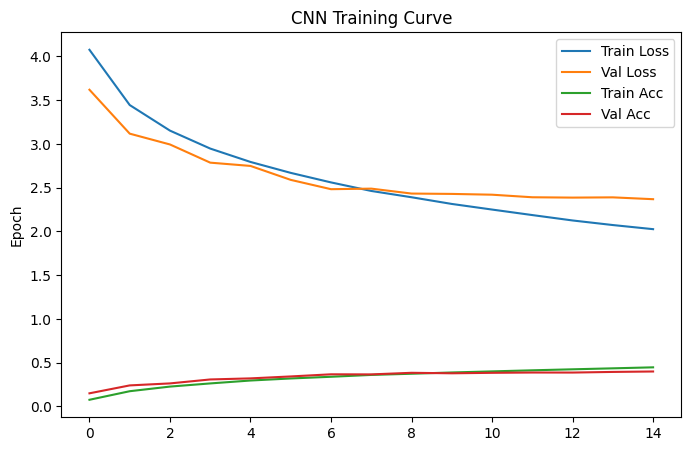

CNN (Fine Labels) RESULTS
CNN (Fine Labels) Accuracy: 0.4107


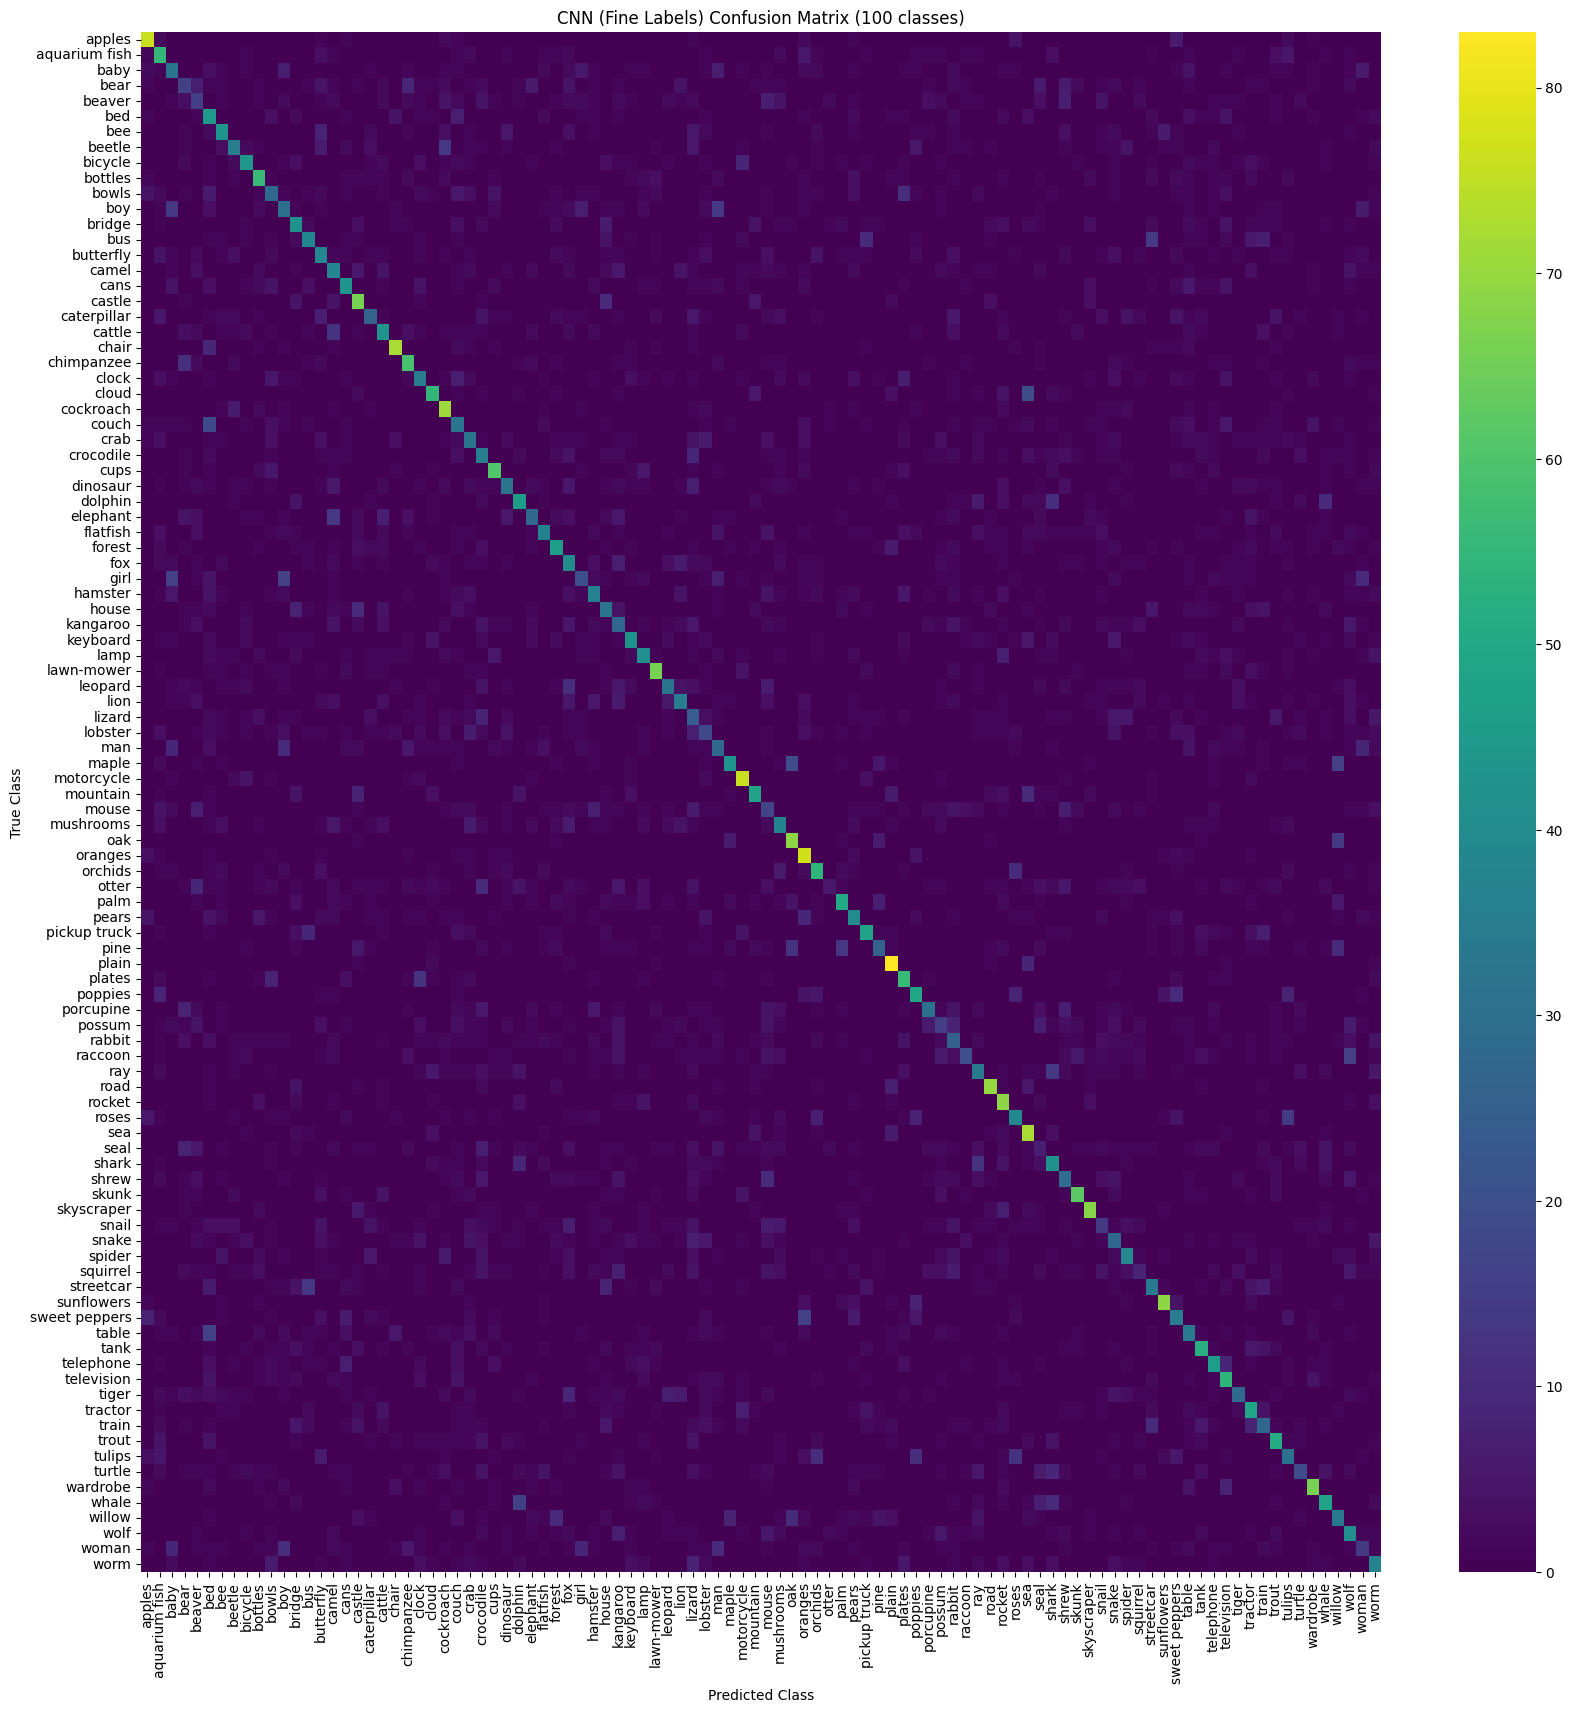


Worst-performing classes:
   Class Name  Accuracy
55      otter      0.05
72       seal      0.07
80   squirrel      0.08
77      snail      0.14
98      woman      0.14

Best-performing classes:
    Class Name  Accuracy
71         sea      0.72
48  motorcycle      0.76
0       apples      0.76
53     oranges      0.77
60       plain      0.83

Classes with 0% accuracy: 0

Mean accuracy per coarse class:
                      Coarse Class  Mean Accuracy
0                  aquatic mammals       0.526667
1                             fish       0.433333
2                          flowers       0.320000
3                  food containers       0.280000
4             fruit and vegetables       0.438000
5     household electrical devices       0.311429
6              household furniture       0.356667
7                          insects       0.472000
8                 large carnivores       0.433333
9    large man-made outdoor things       0.310000
10    large natural outdoor scenes       

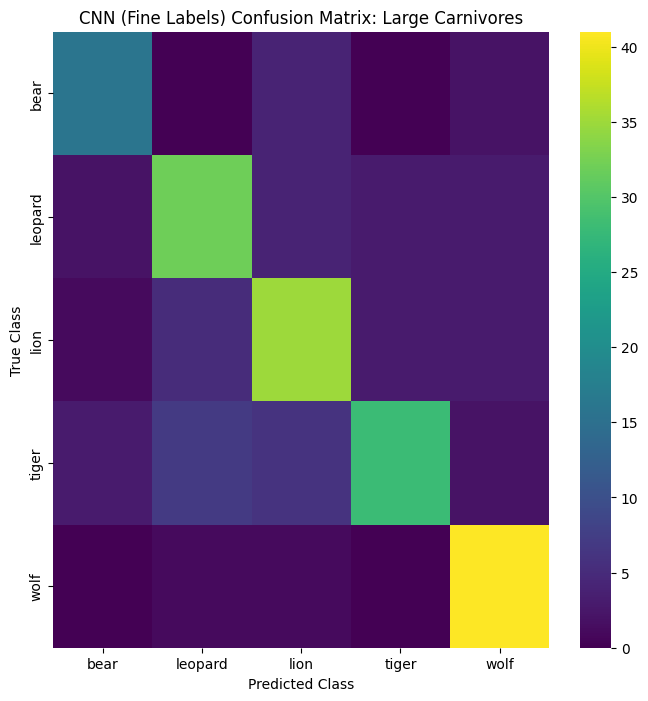

In [5]:
best_f = None
best_d = None
best_k = None
best_cnn_acc = 0
best_cnn_model = None
best_history = None

y_train_fine = to_categorical(trnLabel_fine)

filter_values = [32, 64]
depth_values = [2, 3]
kernel_values = [(3,3), (5,5)]

if RUN_HYPERPARAMETER_SEARCH:
    print("Finding best set of Hyperparameters for CNN...")
    for f in filter_values:
        for d in depth_values:
            for k in kernel_values:
                print(f"\nTraining CNN: filters={f}, depth={d}, kernel={k}, num_classes=100")

                model = make_cnn(f, d, k, 100)
                model.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

                hist = model.fit(train_images, y_train_fine, epochs=15, batch_size=64, shuffle=True, validation_split=0.1, verbose=0)

                pred = model.predict(test_images, verbose=0)
                pred_labels = np.argmax(pred, axis=1)
                acc = accuracy_score(tstLabel_fine, pred_labels)

                print("Accuracy:", acc)

                if acc > best_cnn_acc:
                    best_f = f
                    best_d = d
                    best_k = k
                    best_cnn_acc = acc
                    best_cnn_model = model
                    best_history = hist
else:
    best_f, best_d, best_k = 64, 3, (3,3)
    best_cnn_model = make_cnn(best_f, best_d, best_k, 100)
    best_cnn_model.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    best_history = best_cnn_model.fit(train_images, y_train_fine, epochs=15, batch_size=64, shuffle=True, validation_split=0.1, verbose=0)

pred = best_cnn_model.predict(test_images, verbose=0)
pred_labels = np.argmax(pred, axis=1)

plt.figure(figsize=(8,5))
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Val Loss')
plt.plot(best_history.history['accuracy'], label='Train Acc')
plt.plot(best_history.history['val_accuracy'], label='Val Acc')
plt.ylabel("Metric")
plt.ylabel("Epoch")
plt.legend()
plt.title("CNN Training Curve")
plt.show()

cnn_acc, df_cnn_per_class, df_cnn_coarse = evaluate_model(
    tstLabel_fine,
    pred_labels,
    model_name="CNN (Fine Labels)",
    fine_labels=fine_labels,
    coarse_labels=coarse_labels,
    trnLabel_fine=trnLabel_fine,
    trnLabel_coarse=trnLabel_coarse,
    show_full_cm=True,
    show_subregion=True
)

The CNN achieves the highest fine-label accuracy, illustrating the advantage of end-to-end feature learning over hand-crafted descriptors. Errors are more structured and often confined within the same coarse class, suggesting that the model captures meaningful semantic hierarchies despite the low image resolution.

Inspection of misclassified examples reveals that many errors occur between visually similar classes (e.g., different species of animals or vehicles with similar silhouettes), highlighting the intrinsic difficulty of fine-grained classification at low resolution. Training curves indicate stable convergence with no severe overfitting.

### 6.1 CNN Classification Using Coarse-Grained Labels

Creating CNN using coarse labels (with previous Hyperparameters)...


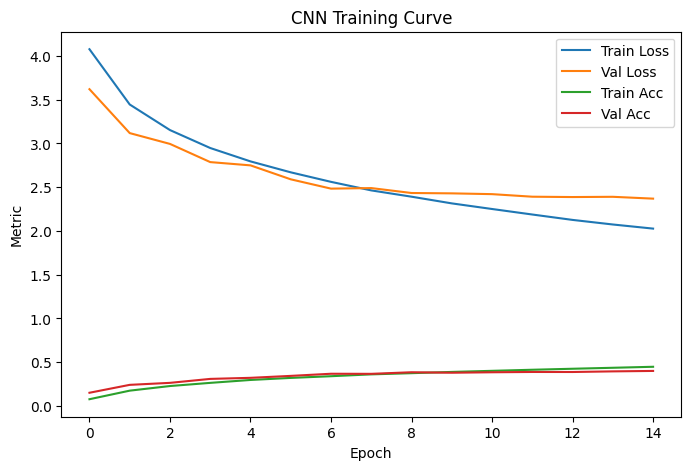

CNN (Coarse Labels) Accuracy: 0.5481


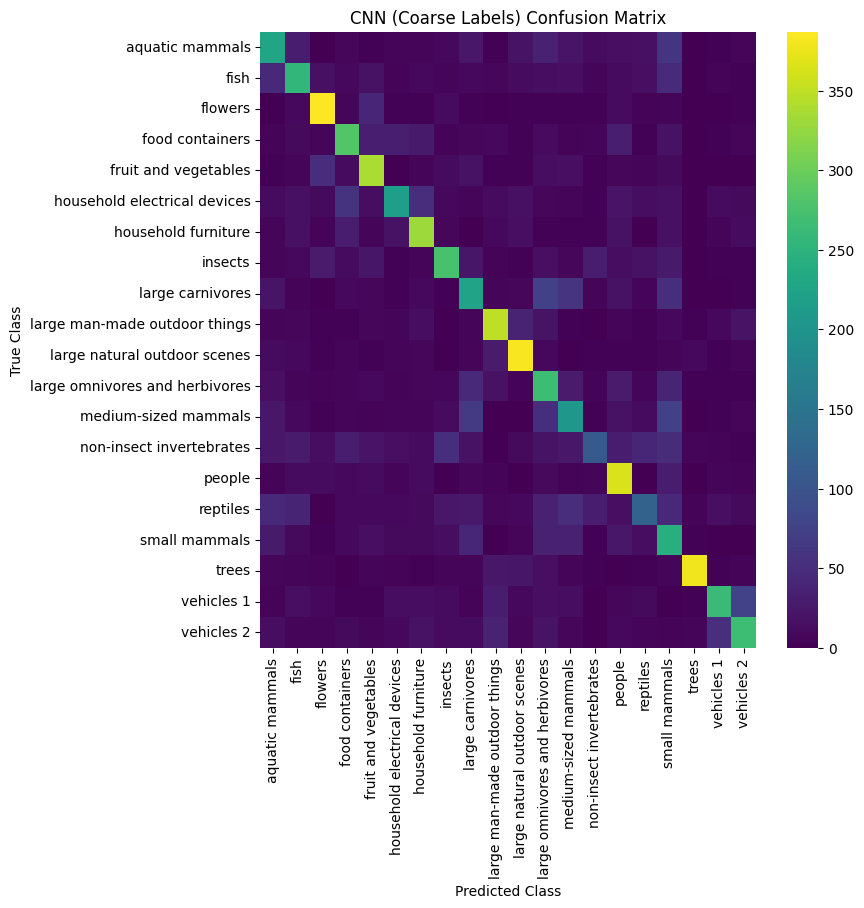

In [6]:
print("Creating CNN using coarse labels (with previous Hyperparameters)...")
model_coarse = make_cnn(best_f, best_d, best_k, num_classes=20)
model_coarse.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

hist = model_coarse.fit(train_images, to_categorical(trnLabel_coarse), epochs=15, batch_size=64, shuffle=True, verbose=0)

coarse_pred = np.argmax(model_coarse.predict(test_images, verbose=0), axis=1)

plt.figure(figsize=(8,5))
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Val Loss')
plt.plot(best_history.history['accuracy'], label='Train Acc')
plt.plot(best_history.history['val_accuracy'], label='Val Acc')
plt.ylabel("Metric")
plt.xlabel("Epoch")
plt.legend()
plt.title("CNN Training Curve")
plt.show()

coarse_cnn_acc, coarse_cnn_cm = evaluate_coarse_model(
    tstLabel_coarse,
    coarse_pred,
    coarse_labels=coarse_labels,
    model_name="CNN (Coarse Labels)",
)

The coarse-label CNN is evaluated separately using coarse labels only, as fine-grained per-class analysis is not applicable in the reduced label space. Training the CNN on coarse labels results in a substantial accuracy improvement, reflecting reduced class ambiguity and stronger visual coherence at higher semantic levels. This outcome demonstrates the impact of label granularity on recognition performance and aligns with the hierarchical structure of the CIFAR-100 dataset.

### 7. Quantitative Results and Comparative Evaluation

To enable a fair comparison, all models were evaluated using identical metrics, including overall accuracy, per-class accuracy, and confusion matrices. Results were aggregated to allow direct comparison across methods. Normalised confusion matrices and class-level accuracy analysis reveal consistent performance gains from feature learning, with the CNN substantially reducing inter-class confusion. Accuracy is used as the primary metric because CIFAR-100 is perfectly balanced across both fine and coarse labels.

Table 1:


,Method,Fine Accuracy,Sub-region Accuracy (Large Carnivores),Mean Coarse Accuracy
0,GMM,0.0894,0.058,0.091690
1,HOG+SVM,0.1935,0.094,0.196883
2,CNN,0.4107,0.304,0.416233


Table 2:


,Class Name,GMM,HOG+SVM,CNN,Mean Accuracy
72,seal,0.00,0.01,0.07,0.026667
55,otter,0.00,0.04,0.05,0.030000
80,squirrel,0.00,0.07,0.08,0.050000
4,beaver,0.00,0.01,0.15,0.053333
77,snail,0.00,0.05,0.14,0.063333
64,possum,0.07,0.02,0.15,0.080000
3,bear,0.00,0.08,0.16,0.080000
50,mouse,0.00,0.08,0.17,0.083333
66,raccoon,0.00,0.06,0.20,0.086667
45,lobster,0.00,0.09,0.18,0.090000


Table GMM:


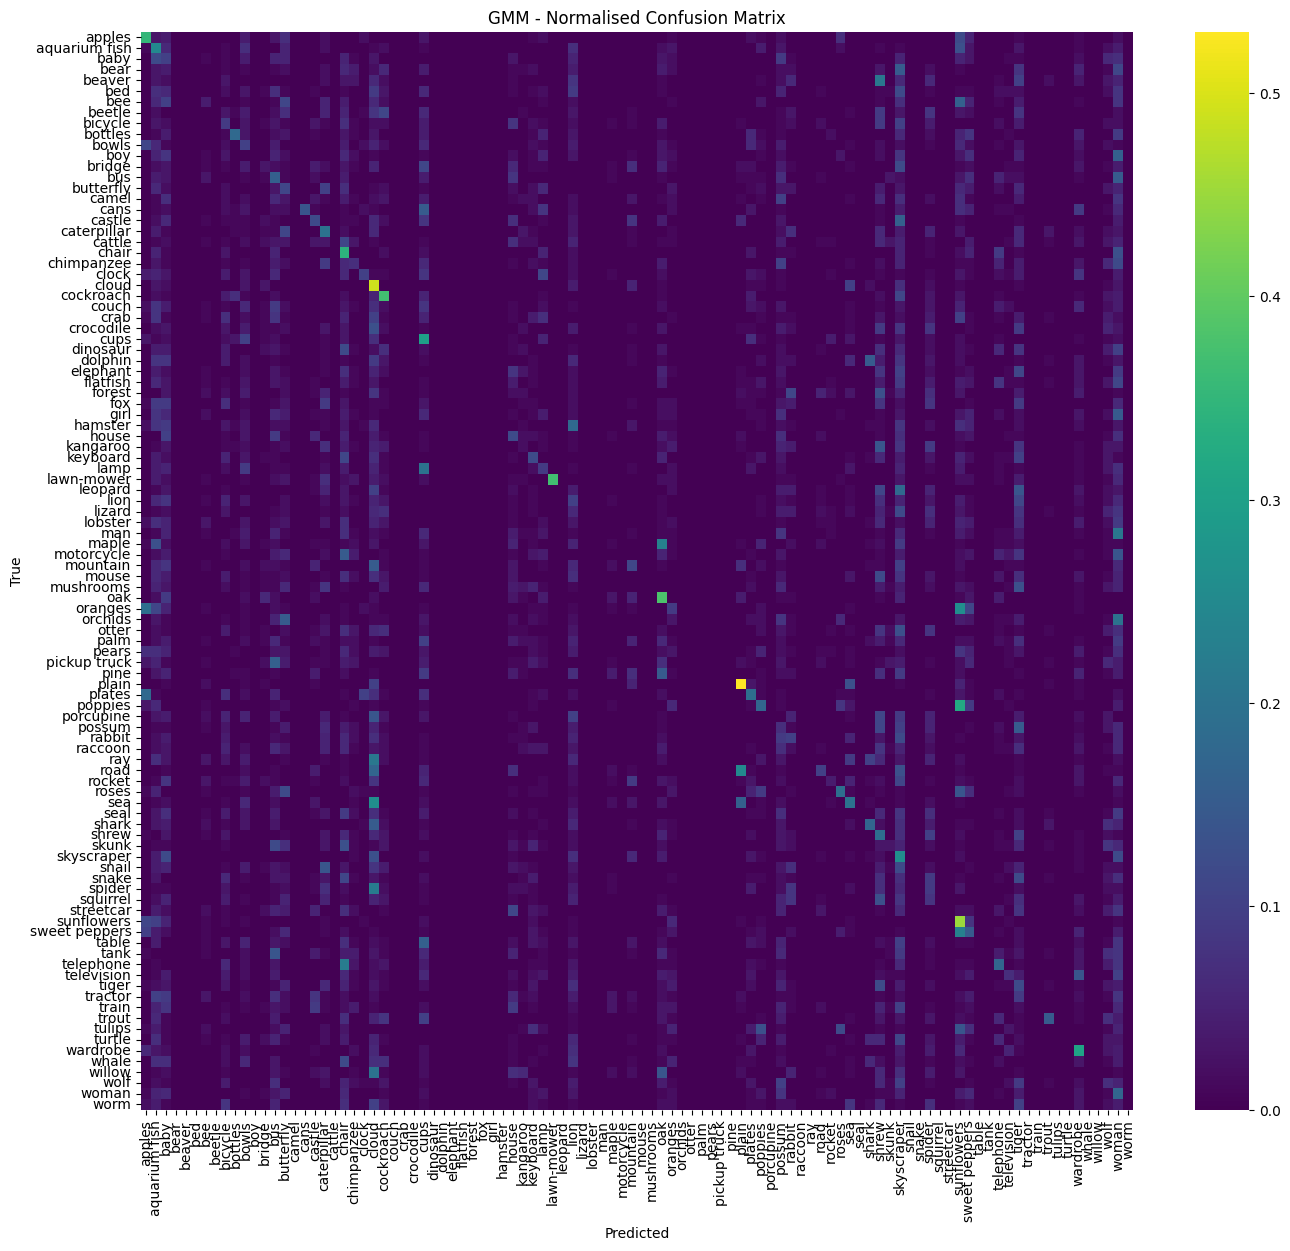

Table HOG+SVM:


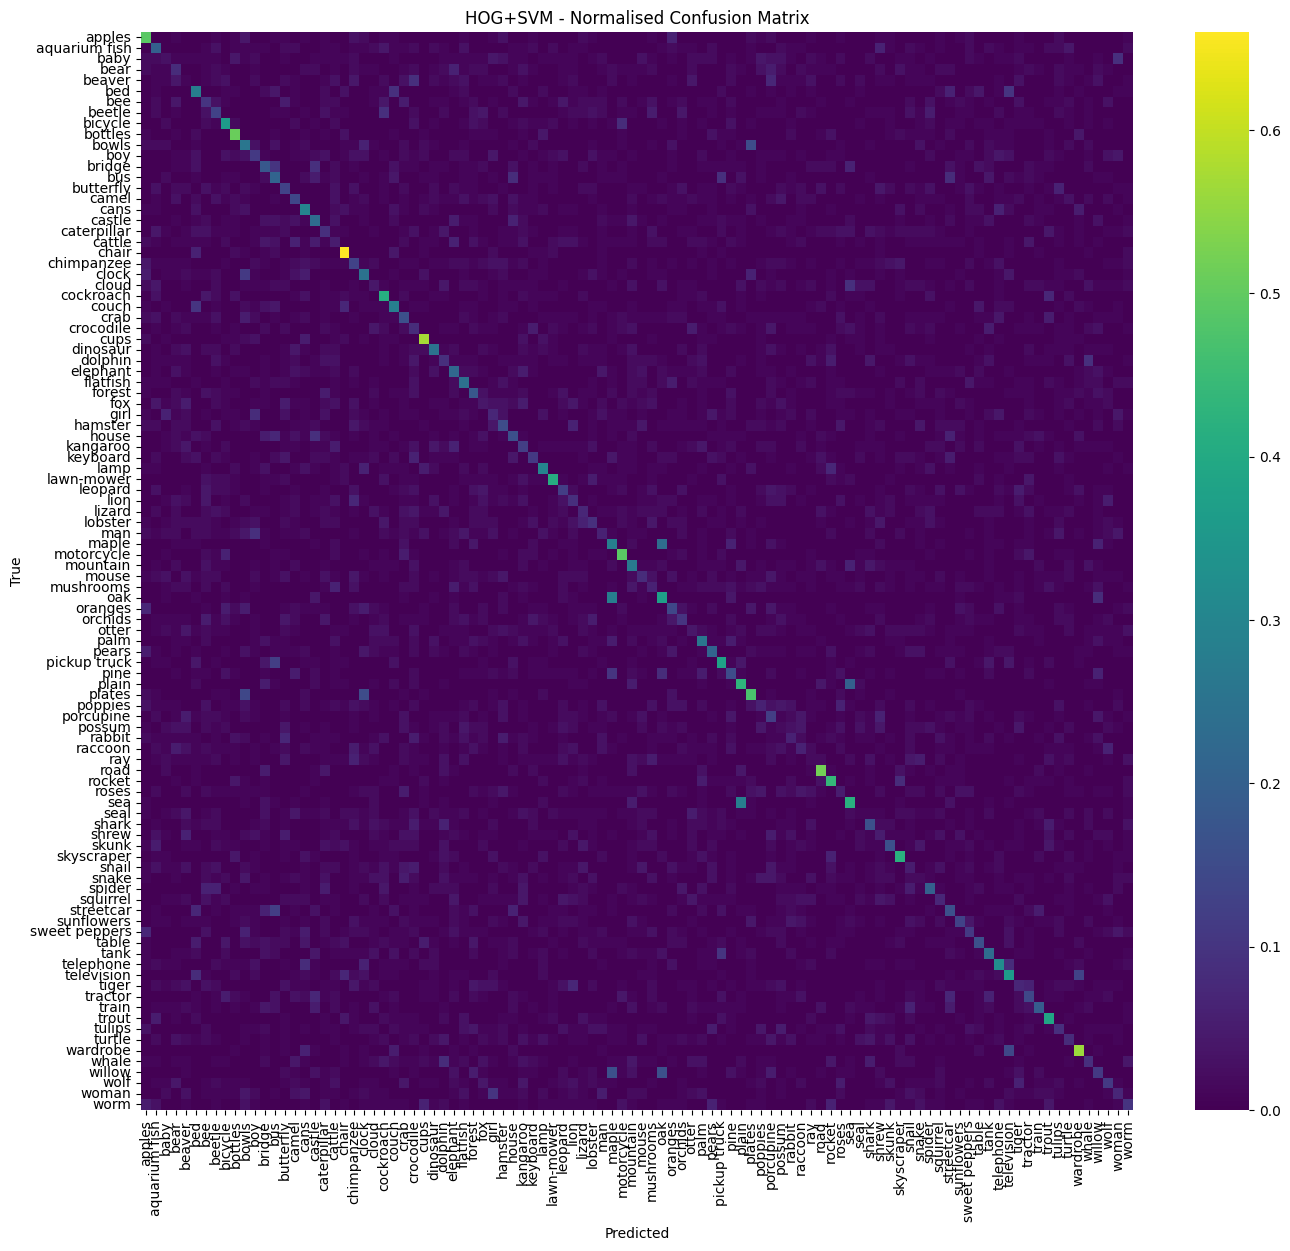

Table CNN:


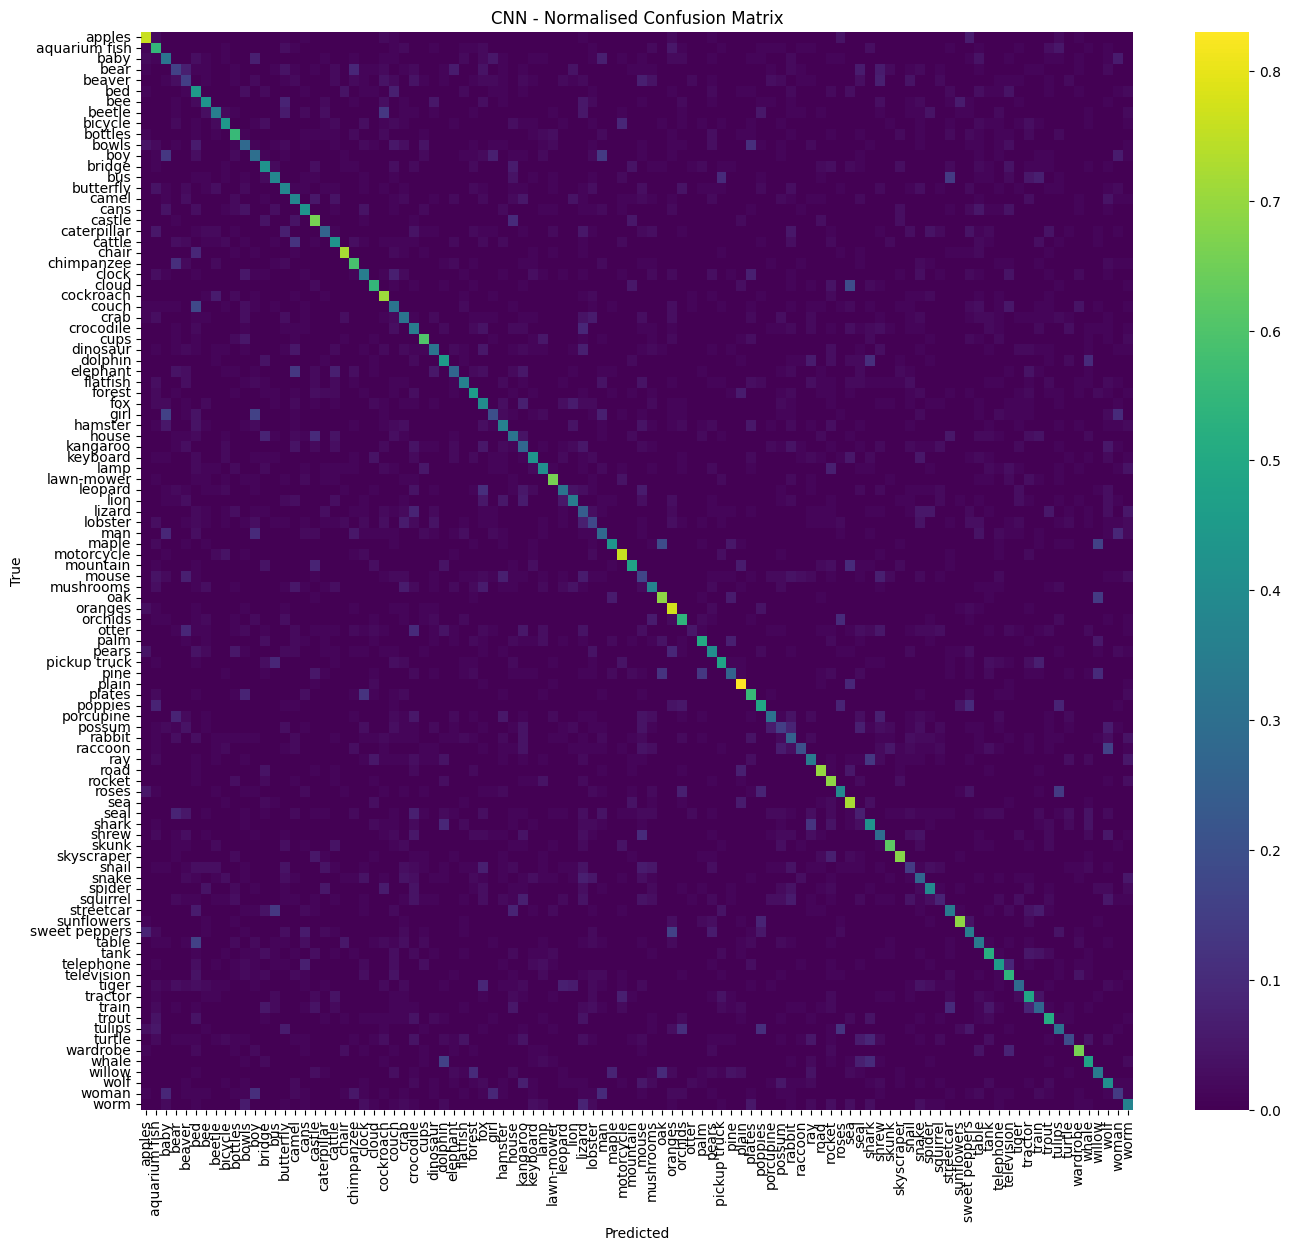

In [15]:
results = {}

results["GMM"] = evaluate_model_summary(tstLabel_fine, gmm_pred, "GMM Baseline", fine_labels, coarse_labels, trnLabel_coarse)

results["HOG+SVM"] = evaluate_model_summary(tstLabel_fine, best_svm_pred, "HOG + SVM", fine_labels, coarse_labels, trnLabel_coarse)

results["CNN"] = evaluate_model_summary(tstLabel_fine, pred_labels, "CNN (Fine)", fine_labels, coarse_labels, trnLabel_coarse)

summary_df = pd.DataFrame([
    {
        "Method": k,
        "Fine Accuracy": v["accuracy"],
        "Sub-region Accuracy (Large Carnivores)": v["subregion_accuracy"],
        "Mean Coarse Accuracy": v["coarse"]["Accuracy"].mean()
    }
    for k, v in results.items()
])

summary_df = summary_df.sort_values("Fine Accuracy", ascending=True)
print("Table 1:")
display(summary_df)

merged = results["GMM"]["per_class"][["Class Name", "Accuracy"]].rename(columns={"Accuracy": "GMM"})
merged = merged.merge(results["HOG+SVM"]["per_class"][["Class Name", "Accuracy"]], on="Class Name").rename(columns={"Accuracy": "HOG+SVM"})
merged = merged.merge(results["CNN"]["per_class"][["Class Name", "Accuracy"]], on="Class Name").rename(columns={"Accuracy": "CNN"})

merged["Mean Accuracy"] = merged[["GMM", "HOG+SVM", "CNN"]].mean(axis=1)

print("Table 2:")
display(merged.sort_values("Mean Accuracy").head(10))

def plot_cm_normalised(cm, title, labels):
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(16,14))
    sns.heatmap(cm_norm, cmap="viridis", cbar=True, xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

for k, v in results.items():
    print(f"Table {k}:")
    plot_cm_normalised(v["confusion_matrix"], f"{k} - Normalised Confusion Matrix", fine_labels)

In addition to overall fine-label accuracy, sub-region accuracy was computed for a representative coarse class (“large carnivores”) to assess each model’s ability to discriminate between visually similar fine-grained categories. This analysis provides a more targeted evaluation of fine-grained recognition performance within a semantically coherent subset of the dataset.

As shown in the first table, all methods exhibit a notable drop in accuracy within the selected sub-region compared to their global performance, highlighting the intrinsic difficulty of fine-grained classification even when semantic context is constrained.

###### GMM
The near-random sub-region accuracy confirms that unsupervised clustering fails to capture discriminative structure even within a single semantic group.
###### HOG + SVM
Improved sub-region accuracy demonstrates the benefit of gradient-based features, though confusion persists among classes with similar forms.
###### CNN
The CNN achieves the highest sub-region accuracy, indicating superior feature learning, yet remaining errors highlight the limits imposed by low image resolution.

### 8. Confusion Matrix and Error Pattern Analysis

Confusion matrices reveal that:
Classical methods frequently confuse visually similar categories,
CNN errors are often confined within the same coarse class,
Coarse-label classification is far more reliable than fine-label classification.
All confusion matrices are row-normalised to reflect per-class error patterns.

Sub-region confusion matrices for the “large carnivores” super-class reveal that misclassifications predominantly occur between visually similar species. While the CNN significantly outperforms classical approaches in this sub-region, confusion remains non-trivial, indicating that learned representations still struggle with subtle inter-class differences at low spatial resolution. These findings reinforce the importance of sub-region analysis as a complementary evaluation to aggregate accuracy metrics.

### 9. Conclusion and Discussion

This study compared classical and deep learning approaches for object recognition on CIFAR-100. The GMM baseline performed poorly, demonstrating that unsupervised clustering of raw pixels is insufficient for this task. HOG features combined with an SVM provided a strong classical baseline, but performance was limited by the representational capacity of hand-crafted features.
The CNN achieved the best performance, confirming the effectiveness of end-to-end feature learning for image classification. Results also show that classification accuracy increases substantially when predicting coarse labels rather than fine labels, reflecting the hierarchical structure of the dataset.
Despite these successes, fine-grained object recognition remains challenging, particularly for visually similar categories.

### 10. Limitations and Future Work

This study evaluates models using a single fixed train–test split, without repeated runs or cross-validation, meaning performance variability due to random initialisation is not explicitly measured. The low spatial resolution of CIFAR-100 images and the presence of visually ambiguous fine-grained classes inherently limit achievable accuracy. Furthermore, model selection is guided by test-set performance due to dataset constraints, and hierarchical label relationships are not explicitly exploited during fine-label training.

### 11. Reproducibility

All experiments were conducted using fixed train–test splits provided with CIFAR-100. Random seeds were controlled where applicable, and hyperparameter search spaces were constrained to ensure reproducibility under limited computational resources.